<a href="https://colab.research.google.com/github/Daksh-create349/Diabetic-Retinopathy-Trained/blob/main/Diabetic_retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1: GPU SETUP

import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "❌ T4 GPU not detected. Connect to a T4 runtime first."
    )

print("✅ GPU:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

# Faster training on T4
mixed_precision.set_global_policy("mixed_float16")

print("✅ Mixed precision:", mixed_precision.global_policy())

✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision: <DTypePolicy "mixed_float16">


In [2]:
# CELL 2: IMPORTS

import os
import zipfile
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from getpass import getpass

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow import keras
from tensorflow.keras import layers

print("✅ Imports successful")

✅ Imports successful


In [3]:
# CELL 3: KAGGLE AUTHENTICATION

token = getpass("Paste Kaggle token: ").strip()
token = "".join(token.split())

if not token:
    raise ValueError("❌ Token is empty.")

if not token.startswith("KGAT_"):
    raise ValueError("❌ Token must start with KGAT_.")

if not token.isascii():
    raise ValueError("❌ Token contains invalid characters.")

os.environ["KAGGLE_API_TOKEN"] = token

print("✅ Kaggle token accepted")

Paste Kaggle token: ··········
✅ Kaggle token accepted


In [4]:
# CELL 4: DOWNLOAD APTOS

APTOS_DIR = Path("/content/APTOS")
APTOS_DIR.mkdir(parents=True, exist_ok=True)

!kaggle datasets download \
    -d mariaherrerot/aptos2019 \
    -p /content/APTOS \
    --force

print("✅ Dataset downloaded")

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [07:16<00:00, 19.7MB/s]

✅ Dataset downloaded


In [5]:
# CELL 5: EXTRACT AND SET PATHS

zip_files = list(APTOS_DIR.glob("*.zip"))

if not zip_files:
    raise FileNotFoundError("❌ APTOS ZIP not found.")

with zipfile.ZipFile(zip_files[0], "r") as z:
    z.extractall(APTOS_DIR)

TRAIN_CSV = APTOS_DIR / "train_1.csv"
VAL_CSV = APTOS_DIR / "valid.csv"
TEST_CSV = APTOS_DIR / "test.csv"

TRAIN_DIR = APTOS_DIR / "train_images" / "train_images"
VAL_DIR = APTOS_DIR / "val_images" / "val_images"
TEST_DIR = APTOS_DIR / "test_images" / "test_images"

required = [
    TRAIN_CSV,
    VAL_CSV,
    TEST_CSV,
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
]

for p in required:
    if not p.exists():
        raise FileNotFoundError(f"❌ Missing: {p}")

print("✅ Dataset structure verified")

✅ Dataset structure verified


In [6]:
# CELL 6: LOAD DATA

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

IMAGE_COL = train_df.columns[0]
LABEL_COL = train_df.columns[1]

def find_image(folder, image_id):
    image_id = str(image_id)

    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{image_id}{ext}"
        if p.exists():
            return str(p)

    return None


train_df["image_path"] = train_df[IMAGE_COL].apply(
    lambda x: find_image(TRAIN_DIR, x)
)

val_df["image_path"] = val_df[IMAGE_COL].apply(
    lambda x: find_image(VAL_DIR, x)
)

test_df["image_path"] = test_df[IMAGE_COL].apply(
    lambda x: find_image(TEST_DIR, x)
)

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing = df["image_path"].isna().sum()

    print(
        f"{name}: {len(df)} images | Missing: {missing}"
    )

    if missing:
        raise FileNotFoundError(
            f"❌ Missing images in {name}"
        )

print("✅ Data loaded and matched")

Train: 2930 images | Missing: 0
Validation: 366 images | Missing: 0
Test: 366 images | Missing: 0
✅ Data loaded and matched


diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


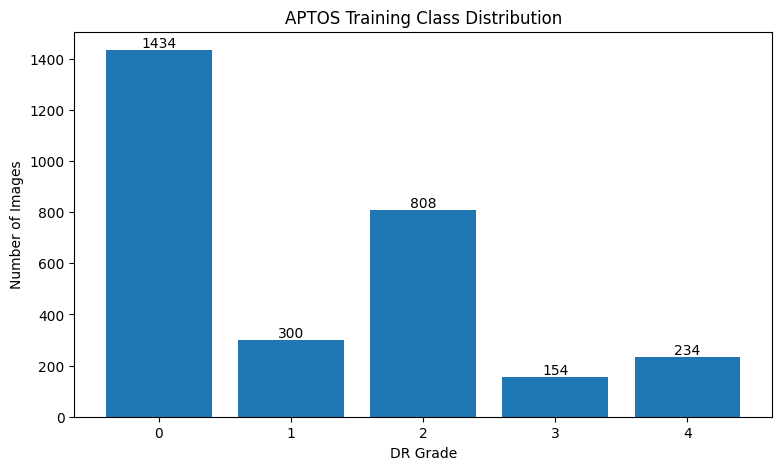

In [7]:
# CELL 7: CLASS DISTRIBUTION

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative"
}

counts = train_df[LABEL_COL].value_counts().sort_index()

print(counts)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("APTOS Training Class Distribution")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.show()

In [14]:
# FIX: EfficientNet-compatible preprocessing

IMG_SIZE = 384

def preprocess_image(path):

    image = cv2.imread(path)

    if image is None:
        raise ValueError(f"Cannot read image: {path}")

    # Crop black borders
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    mask = np.where(
        gray > 10,
        255,
        0
    ).astype(np.uint8)

    coords = cv2.findNonZero(mask)

    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)

        if w > 0 and h > 0:
            image = image[y:y+h, x:x+w]

    # BGR -> RGB
    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # IMPORTANT:
    # Keep pixel values in 0-255.
    # EfficientNet handles its own input scaling.
    return image.astype(np.float32)


print("✅ Preprocessing fixed")

✅ Preprocessing fixed


In [9]:
# CELL 9: RAM-SAFE DATA PIPELINE

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image_tf(path, label):

    def loader(path_bytes):
        path_string = path_bytes.decode("utf-8")

        image = preprocess_image(path_string)

        return image.astype(np.float32)

    image = tf.numpy_function(
        loader,
        [path],
        tf.float32
    )

    image.set_shape(
        [IMG_SIZE, IMG_SIZE, 3]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


def make_dataset(df, training=False):

    paths = df["image_path"].values
    labels = df[LABEL_COL].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image_tf,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

print("✅ RAM-safe pipeline created")

✅ RAM-safe pipeline created


Shape: (384, 384, 3)
Dtype: float32
Min: 0.0
Max: 255.0


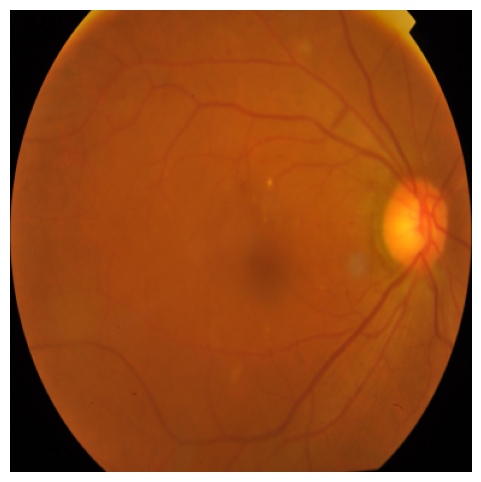

In [15]:
# TEST THE FIX

sample_path = train_df.iloc[0]["image_path"]

sample_image = preprocess_image(
    sample_path
)

print("Shape:", sample_image.shape)
print("Dtype:", sample_image.dtype)
print("Min:", sample_image.min())
print("Max:", sample_image.max())

plt.figure(figsize=(6, 6))
plt.imshow(sample_image.astype(np.uint8))
plt.axis("off")
plt.show()

In [11]:
# CELL 11: CLASS WEIGHTS + AUGMENTATION

classes = np.sort(
    train_df[LABEL_COL].unique()
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df[LABEL_COL].values
)

class_weights = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

print("Class weights:")
for c, w in class_weights.items():
    print(f"Grade {c}: {w:.4f}")


augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(
        height_factor=(-0.08, 0.08),
        width_factor=(-0.08, 0.08)
    ),
    layers.RandomContrast(0.15)
])

print("✅ Class balancing + augmentation ready")

Class weights:
Grade 0: 0.4086
Grade 1: 1.9533
Grade 2: 0.7252
Grade 3: 3.8052
Grade 4: 2.5043
✅ Class balancing + augmentation ready


In [12]:
# CELL 12: BUILD MODEL

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

base_model.trainable = False


inputs = keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

x = augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.35)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.25)(x)

outputs = layers.Dense(
    5,
    activation="softmax",
    dtype="float32"
)(x)


model = keras.Model(
    inputs,
    outputs,
    name="APTOS_DR_EfficientNetB3"
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("✅ EfficientNetB3 ready")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ EfficientNetB3 ready


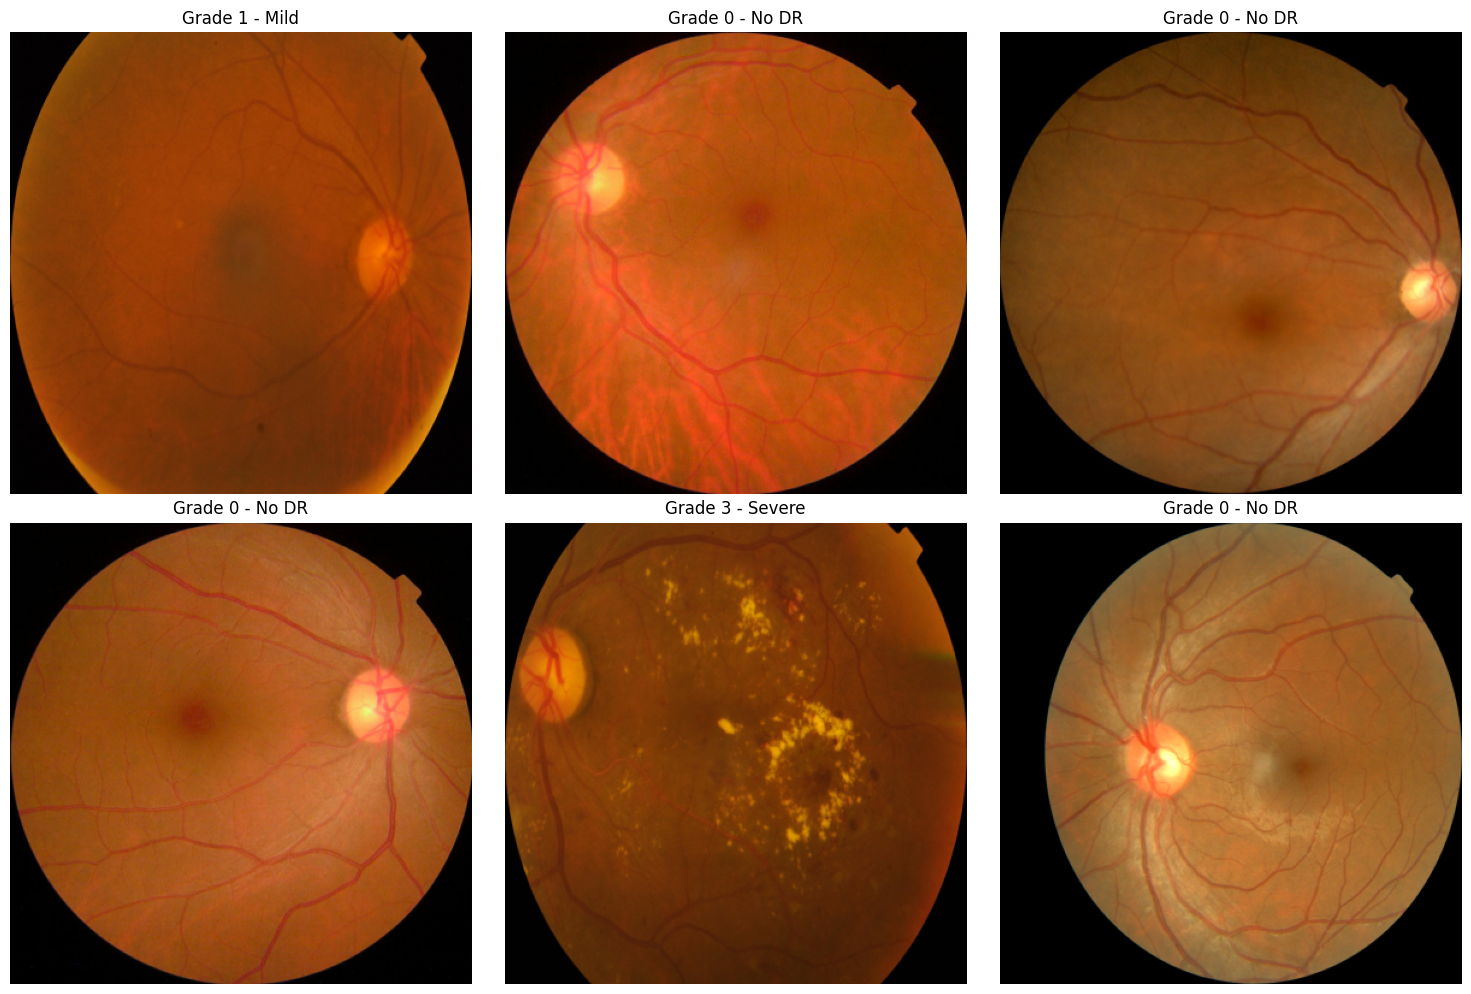

In [16]:
# CHECK IMAGE + LABEL PAIRING

plt.figure(figsize=(15, 10))

sample_df = train_df.sample(
    n=6,
    random_state=42
)

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = preprocess_image(
        row["image_path"]
    )

    grade = int(
        row[LABEL_COL]
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        image.astype(np.uint8)
    )

    plt.title(
        f"Grade {grade} - {class_names[grade]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# FAST GPU-FRIENDLY DATA PIPELINE

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def decode_and_preprocess(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    # Keep 0-255 because EfficientNet handles scaling
    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def make_dataset(dataframe, training=False):

    paths = dataframe[
        "image_path"
    ].values.astype(str)

    labels = dataframe[
        LABEL_COL
    ].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        decode_and_preprocess,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE
    )

    ds = ds.prefetch(
        AUTOTUNE
    )

    return ds


train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

print("✅ Fast TensorFlow pipeline ready")

✅ Fast TensorFlow pipeline ready


In [18]:
# TEST NEW PIPELINE

for images, labels in train_ds.take(1):

    print("Batch shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Min pixel:", float(tf.reduce_min(images)))
    print("Max pixel:", float(tf.reduce_max(images)))

print("✅ Pipeline working")

Batch shape: (32, 384, 384, 3)
Labels shape: (32,)
Min pixel: 0.0
Max pixel: 255.0
✅ Pipeline working


In [19]:
# TRAINING — STAGE 1

MODEL_DIR = Path(
    "/content/drive/MyDrive/DR_Screening/models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL = MODEL_DIR / "best_aptos_model.keras"


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]


history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5144 - loss: 1.7098
Epoch 1: val_accuracy improved from None to 0.59563, saving model to /content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.6055 - loss: 1.4729 - val_accuracy: 0.5956 - val_loss: 0.9890 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6870 - loss: 1.1437
Epoch 2: val_accuracy improved from 0.59563 to 0.72951, saving model to /content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.6928 - loss: 1.0534 - val_accuracy: 0.7295 - val_loss: 0.6582 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7099 - loss: 0.9

In [20]:
# STAGE 2: FINE-TUNING

# Unfreeze the EfficientNet backbone
base_model.trainable = True

# Freeze the first 70% of layers
freeze_until = int(
    len(base_model.layers) * 0.70
)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

for layer in base_model.layers[freeze_until:]:
    layer.trainable = True


# Recompile with a much smaller learning rate
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("✅ Fine-tuning enabled")
print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

✅ Fine-tuning enabled
Trainable backbone layers: 116


In [22]:
# RESTORE BEST STAGE-1 MODEL

model = keras.models.load_model(
    "/content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras"
)

print("✅ Best Stage-1 model restored")

✅ Best Stage-1 model restored


12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step

🎯 Validation Accuracy: 73.22%

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR     0.9822    0.9651    0.9736       172
         Mild DR     0.4179    0.7000    0.5234        40
     Moderate DR     0.7042    0.4808    0.5714       104
       Severe DR     0.3077    0.5455    0.3934        22
Proliferative DR     0.6000    0.4286    0.5000        28

        accuracy                         0.7322       366
       macro avg     0.6024    0.6240    0.5924       366
    weighted avg     0.7718    0.7322    0.7390       366


CONFUSION MATRIX
[[166   4   2   0   0]
 [  1  28   8   2   1]
 [  2  28  50  20   4]
 [  0   3   4  12   3]
 [  0   4   7   5  12]]


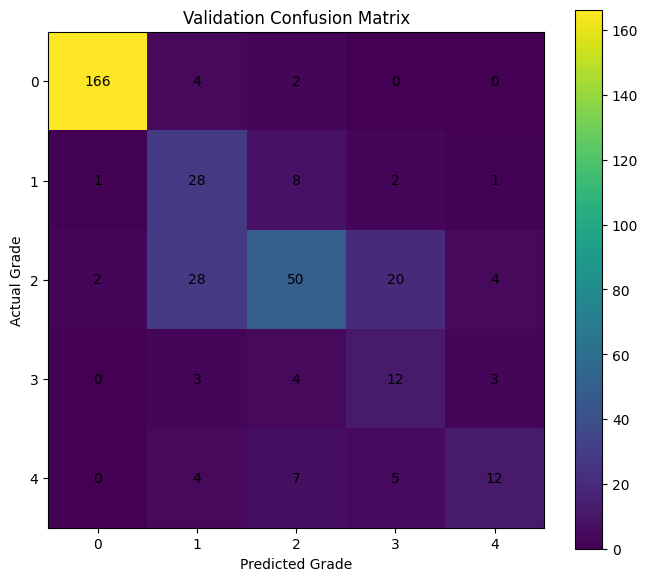


REFERABLE DR
Sensitivity: 75.97%
Specificity: 93.87%

Referable DR confusion matrix:
[[199  13]
 [ 37 117]]


In [23]:
# VALIDATION ERROR ANALYSIS
# IMPORTANT: Test set ko abhi touch nahi kar rahe.

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Predictions on VALIDATION set
val_prob = model.predict(
    val_ds,
    verbose=1
)

val_pred = np.argmax(
    val_prob,
    axis=1
)

val_true = val_df[LABEL_COL].values.astype(
    np.int32
)

# 1. Overall validation accuracy
val_accuracy = np.mean(
    val_pred == val_true
)

print(
    f"\n🎯 Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)


# 2. Per-class performance
print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        val_true,
        val_pred,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "No DR",
            "Mild DR",
            "Moderate DR",
            "Severe DR",
            "Proliferative DR"
        ],
        digits=4,
        zero_division=0
    )
)


# 3. Confusion Matrix
cm = confusion_matrix(
    val_true,
    val_pred,
    labels=[0, 1, 2, 3, 4]
)

print("\nCONFUSION MATRIX")
print(cm)


# 4. Visual confusion matrix
plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title(
    "Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Grade"
)

plt.ylabel(
    "Actual Grade"
)

plt.xticks(
    range(5),
    ["0", "1", "2", "3", "4"]
)

plt.yticks(
    range(5),
    ["0", "1", "2", "3", "4"]
)

plt.colorbar()

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


# 5. Referable DR performance
# Grade 0-1 = Non-referable
# Grade 2-4 = Referable

val_true_ref = (
    val_true >= 2
).astype(int)

val_pred_ref = (
    val_pred >= 2
).astype(int)


ref_cm = confusion_matrix(
    val_true_ref,
    val_pred_ref,
    labels=[0, 1]
)

tn, fp, fn, tp = ref_cm.ravel()

sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

print("\nREFERABLE DR")
print("=" * 60)

print(
    f"Sensitivity: "
    f"{sensitivity * 100:.2f}%"
)

print(
    f"Specificity: "
    f"{specificity * 100:.2f}%"
)

print("\nReferable DR confusion matrix:")
print(ref_cm)

Thresholds meeting SIH targets:
Best threshold: 0.33
Sensitivity: 90.91%
Specificity: 90.57%


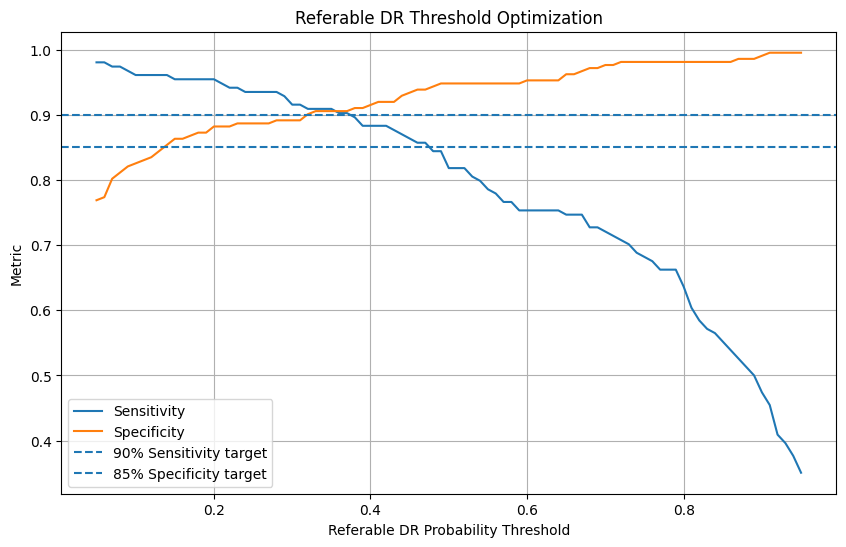

In [24]:
# OPTIMIZE REFERABLE-DR THRESHOLD
# Validation set only — test set remains untouched.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Probability of being referable:
# Grade 2 + Grade 3 + Grade 4
referable_probability = np.sum(
    val_prob[:, 2:5],
    axis=1
)

true_referable = (
    val_true >= 2
).astype(int)


thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

results = []


for threshold in thresholds:

    predicted_referable = (
        referable_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_referable,
        predicted_referable,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    results.append(
        (
            threshold,
            sensitivity,
            specificity
        )
    )


results = np.array(
    results
)

threshold_values = results[:, 0]
sens_values = results[:, 1]
spec_values = results[:, 2]


# Find thresholds satisfying SIH targets
valid = (
    (sens_values >= 0.90)
    &
    (spec_values >= 0.85)
)


print("Thresholds meeting SIH targets:")
print("=" * 60)


if np.any(valid):

    valid_rows = results[valid]

    # Choose highest specificity among
    # thresholds meeting both targets
    best_index = np.argmax(
        valid_rows[:, 2]
    )

    best_threshold = (
        valid_rows[best_index, 0]
    )

    best_sensitivity = (
        valid_rows[best_index, 1]
    )

    best_specificity = (
        valid_rows[best_index, 2]
    )

    print(
        f"Best threshold: "
        f"{best_threshold:.2f}"
    )

    print(
        f"Sensitivity: "
        f"{best_sensitivity * 100:.2f}%"
    )

    print(
        f"Specificity: "
        f"{best_specificity * 100:.2f}%"
    )

else:

    print(
        "⚠️ No threshold simultaneously "
        "reaches 90% sensitivity and 85% specificity."
    )

    # Find threshold closest to sensitivity target
    # while maintaining specificity >= 85%
    spec_valid = (
        spec_values >= 0.85
    )

    if np.any(spec_valid):

        candidate = results[
            spec_valid
        ]

        best_index = np.argmax(
            candidate[:, 1]
        )

        best_threshold = (
            candidate[best_index, 0]
        )

        print(
            f"\nBest sensitivity with "
            f"specificity >=85%:"
        )

        print(
            f"Threshold: "
            f"{best_threshold:.2f}"
        )

        print(
            f"Sensitivity: "
            f"{candidate[best_index, 1] * 100:.2f}%"
        )

        print(
            f"Specificity: "
            f"{candidate[best_index, 2] * 100:.2f}%"
        )


# Plot sensitivity/specificity
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_values,
    sens_values,
    label="Sensitivity"
)

plt.plot(
    threshold_values,
    spec_values,
    label="Specificity"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% Sensitivity target"
)

plt.axhline(
    0.85,
    linestyle="--",
    label="85% Specificity target"
)

plt.xlabel(
    "Referable DR Probability Threshold"
)

plt.ylabel(
    "Metric"
)

plt.title(
    "Referable DR Threshold Optimization"
)

plt.legend()
plt.grid(True)

plt.show()

In [26]:
# GENERATE TEST PREDICTIONS

# Make sure the best model is loaded
model = keras.models.load_model(
    "/content/drive/MyDrive/DR_Screening/models/best_aptos_model.keras"
)

# Generate probability predictions for the test set
y_prob = model.predict(
    test_ds,
    verbose=1
)

# Actual test labels
y_true = test_df[LABEL_COL].values.astype(
    np.int32
)

# Normal 5-class prediction
y_pred = np.argmax(
    y_prob,
    axis=1
)

print("✅ Test predictions generated")

print("Probability shape:", y_prob.shape)
print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step
✅ Test predictions generated
Probability shape: (366, 5)
True labels: (366,)
Predicted labels: (366,)


In [27]:
# FINAL TEST: LOCKED REFERABLE-DR THRESHOLD

REFERRABLE_THRESHOLD = 0.33

# Grade 2 + Grade 3 + Grade 4 probability
test_referable_probability = np.sum(
    y_prob[:, 2:5],
    axis=1
)

# Apply the threshold selected ONLY from validation data
test_pred_referable = (
    test_referable_probability >= REFERRABLE_THRESHOLD
).astype(int)

# Ground truth
test_true_referable = (
    y_true >= 2
).astype(int)


# Confusion matrix
test_ref_cm = confusion_matrix(
    test_true_referable,
    test_pred_referable,
    labels=[0, 1]
)

tn, fp, fn, tp = test_ref_cm.ravel()


# Metrics
test_sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

test_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


print("FINAL TEST REFERABLE-DR RESULTS")
print("=" * 60)

print(
    f"Locked threshold: {REFERRABLE_THRESHOLD:.2f}"
)

print(
    f"Sensitivity: {test_sensitivity * 100:.2f}%"
)

print(
    f"Specificity: {test_specificity * 100:.2f}%"
)

print("\nConfusion Matrix:")
print(test_ref_cm)

FINAL TEST REFERABLE-DR RESULTS
Locked threshold: 0.33
Sensitivity: 93.43%
Specificity: 93.01%

Confusion Matrix:
[[213  16]
 [  9 128]]


In [28]:
# BACKUP MODEL V1
# Your current ~73.22% validation model

from pathlib import Path
import shutil

MODEL_DIR = Path(
    "/content/drive/MyDrive/DR_Screening/models"
)

OLD_MODEL = MODEL_DIR / "best_aptos_model.keras"
BACKUP_MODEL = MODEL_DIR / "MODEL_V1_73pct_backup.keras"

if not OLD_MODEL.exists():
    raise FileNotFoundError(
        f"Model not found: {OLD_MODEL}"
    )

shutil.copy2(
    OLD_MODEL,
    BACKUP_MODEL
)

print("✅ Model V1 backup created")
print("📁", BACKUP_MODEL)

✅ Model V1 backup created
📁 /content/drive/MyDrive/DR_Screening/models/MODEL_V1_73pct_backup.keras


In [29]:
# V2 CELL 1: FOCAL LOSS

import tensorflow as tf

def sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=0.25
):
    """
    Focal loss for imbalanced 5-class DR classification.
    Gives more weight to difficult/misclassified examples.
    """

    def loss_fn(y_true, y_pred):

        y_true = tf.cast(
            tf.reshape(y_true, [-1]),
            tf.int32
        )

        # Avoid log(0)
        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0 - 1e-7
        )

        # One-hot labels
        y_true_one_hot = tf.one_hot(
            y_true,
            depth=5
        )

        # Probability of correct class
        p_t = tf.reduce_sum(
            y_true_one_hot * y_pred,
            axis=-1
        )

        # Focal weighting
        focal_weight = tf.pow(
            1.0 - p_t,
            gamma
        )

        # Cross entropy
        ce = -tf.math.log(p_t)

        focal_loss = (
            alpha
            * focal_weight
            * ce
        )

        return tf.reduce_mean(
            focal_loss
        )

    return loss_fn


focal_loss = sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=0.25
)

print("✅ V2 Focal Loss ready")

✅ V2 Focal Loss ready


In [30]:
# V2 CELL 2: BUILD FRESH MODEL + LOAD V1 WEIGHTS

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from pathlib import Path

V1_MODEL_PATH = Path(
    "/content/drive/MyDrive/"
    "DR_Screening/models/"
    "MODEL_V1_73pct_backup.keras"
)

if not V1_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"❌ V1 backup not found:\n{V1_MODEL_PATH}"
    )

# Fresh EfficientNetB3
base_model_v2 = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_v2.trainable = True

# Use the same architecture as V1
inputs_v2 = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = augmentation(inputs_v2)

x = base_model_v2(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.20)(x)

outputs_v2 = layers.Dense(
    5,
    activation="softmax",
    dtype="float32"
)(x)

model_v2 = keras.Model(
    inputs_v2,
    outputs_v2,
    name="APTOS_DR_EfficientNetB3_V2"
)

# Load V1 learned weights
v1_model = keras.models.load_model(
    V1_MODEL_PATH
)

model_v2.set_weights(
    v1_model.get_weights()
)

print("✅ V1 weights loaded into V2")
print("✅ V1 backup remains untouched")

✅ V1 weights loaded into V2
✅ V1 backup remains untouched


In [31]:
# V2 CELL 3: COMPILE V2 MODEL

model_v2.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=focal_loss,
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("✅ V2 compiled with Focal Loss")

✅ V2 compiled with Focal Loss


In [32]:
# V2 CELL 4: TRAIN V2

V2_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "DR_Screening/models/"
    "MODEL_V2_high_accuracy.keras"
)

v2_callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath=V2_MODEL_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]


history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=v2_callbacks,
    verbose=1
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6312 - loss: 0.1740
Epoch 1: val_accuracy improved from None to 0.75137, saving model to /content/drive/MyDrive/DR_Screening/models/MODEL_V2_high_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DR_Screening/models/MODEL_V2_high_accuracy.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 396s 3s/step - accuracy: 0.6846 - loss: 0.1364 - val_accuracy: 0.7514 - val_loss: 0.1395 - learning_rate: 1.0000e-04
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7664 - loss: 0.0788
Epoch 2: val_accuracy improved from 0.75137 to 0.75410, saving model to /content/drive/MyDrive/DR_Screening/models/MODEL_V2_high_accuracy.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DR_Screening/models/MODEL_V2_high_accuracy.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.7696 - loss: 0.0795 - val_accuracy: 0.7541 - val_loss: 0.1330 - learning_rate: 1.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/ste

12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step

🎯 V2 Validation Accuracy: 80.87%

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR     0.9661    0.9942    0.9799       172
         Mild DR     0.6579    0.6250    0.6410        40
     Moderate DR     0.7168    0.7788    0.7465       104
       Severe DR     0.4211    0.3636    0.3902        22
Proliferative DR     0.5789    0.3929    0.4681        28

        accuracy                         0.8087       366
       macro avg     0.6682    0.6309    0.6452       366
    weighted avg     0.7992    0.8087    0.8020       366


CONFUSION MATRIX
[[171   1   0   0   0]
 [  2  25  12   0   1]
 [  4  10  81   6   3]
 [  0   1   9   8   4]
 [  0   1  11   5  11]]


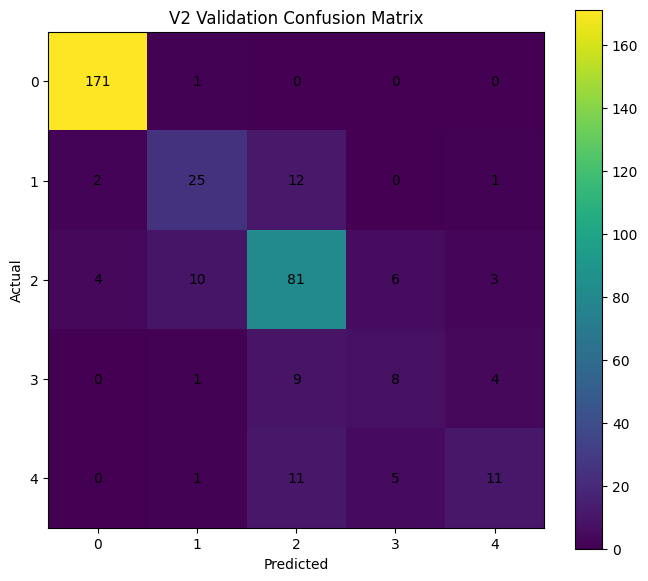

In [33]:
# V2 BEST MODEL — VALIDATION ANALYSIS

V2_BEST_PATH = (
    "/content/drive/MyDrive/"
    "DR_Screening/models/"
    "MODEL_V2_high_accuracy.keras"
)

# Load best V2 checkpoint
model_v2 = keras.models.load_model(
    V2_BEST_PATH,
    custom_objects={
        "loss_fn": focal_loss
    }
)

# Validation predictions
val_prob_v2 = model_v2.predict(
    val_ds,
    verbose=1
)

val_pred_v2 = np.argmax(
    val_prob_v2,
    axis=1
)

val_true_v2 = (
    val_df[LABEL_COL]
    .values
    .astype(np.int32)
)

# Accuracy
v2_val_accuracy = np.mean(
    val_pred_v2 == val_true_v2
)

print(
    f"\n🎯 V2 Validation Accuracy: "
    f"{v2_val_accuracy * 100:.2f}%"
)

# Classification report
print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        val_true_v2,
        val_pred_v2,
        labels=[0,1,2,3,4],
        target_names=[
            "No DR",
            "Mild DR",
            "Moderate DR",
            "Severe DR",
            "Proliferative DR"
        ],
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm_v2 = confusion_matrix(
    val_true_v2,
    val_pred_v2,
    labels=[0,1,2,3,4]
)

print("\nCONFUSION MATRIX")
print(cm_v2)

plt.figure(figsize=(8,7))
plt.imshow(cm_v2)
plt.title("V2 Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(
    range(5),
    ["0","1","2","3","4"]
)
plt.yticks(
    range(5),
    ["0","1","2","3","4"]
)
plt.colorbar()

for i in range(5):
    for j in range(5):
        plt.text(
            j,
            i,
            str(cm_v2[i,j]),
            ha="center",
            va="center"
        )

plt.show()

In [34]:
# BACKUP V2 EXPLICITLY

from pathlib import Path
import shutil

MODEL_DIR = Path(
    "/content/drive/MyDrive/"
    "DR_Screening/models"
)

V2_SOURCE = MODEL_DIR / "MODEL_V2_high_accuracy.keras"

V2_BACKUP = MODEL_DIR / "MODEL_V2_80pct_backup.keras"

if not V2_SOURCE.exists():
    raise FileNotFoundError(
        f"V2 model not found:\n{V2_SOURCE}"
    )

shutil.copy2(
    V2_SOURCE,
    V2_BACKUP
)

print("✅ V2 backup created")
print(V2_BACKUP)

✅ V2 backup created
/content/drive/MyDrive/DR_Screening/models/MODEL_V2_80pct_backup.keras


In [2]:
from google.colab import files

uploaded = files.upload()

Saving MODEL_V2_80pct_backup.keras to MODEL_V2_80pct_backup.keras


In [4]:
# REDEFINE FOCAL LOSS

import tensorflow as tf
from tensorflow import keras

def sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=0.25
):
    def loss_fn(y_true, y_pred):

        y_true = tf.cast(
            tf.reshape(y_true, [-1]),
            tf.int32
        )

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0 - 1e-7
        )

        y_true_one_hot = tf.one_hot(
            y_true,
            depth=5
        )

        p_t = tf.reduce_sum(
            y_true_one_hot * y_pred,
            axis=-1
        )

        focal_weight = tf.pow(
            1.0 - p_t,
            gamma
        )

        cross_entropy = -tf.math.log(p_t)

        focal_loss_value = (
            alpha
            * focal_weight
            * cross_entropy
        )

        return tf.reduce_mean(
            focal_loss_value
        )

    return loss_fn


focal_loss = sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=0.25
)

print("✅ Focal loss ready")

✅ Focal loss ready


In [5]:
# LOAD V2 BACKUP

V2_MODEL_PATH = "/content/MODEL_V2_80pct_backup.keras"

model_v2 = keras.models.load_model(
    V2_MODEL_PATH,
    custom_objects={
        "loss_fn": focal_loss
    }
)

print("✅ V2 model loaded successfully")

✅ V2 model loaded successfully


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 690 variables whereas the saved optimizer has 694 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saving 6959267_orig.jpg to 6959267_orig.jpg

✅ Uploaded: 6959267_orig.jpg

             V2 DR SCREENING RESULT

Predicted Grade : 3
DR Classification: Severe DR
Model Confidence: 59.44%

Referable Probability: 98.65%
Referable DR: YES

Class Probabilities
----------------------------------------
Grade 0 (No DR             ) : 0.00%
Grade 1 (Mild DR           ) : 1.34%
Grade 2 (Moderate DR       ) : 18.06%
Grade 3 (Severe DR         ) : 59.44%
Grade 4 (Proliferative DR  ) : 21.16%


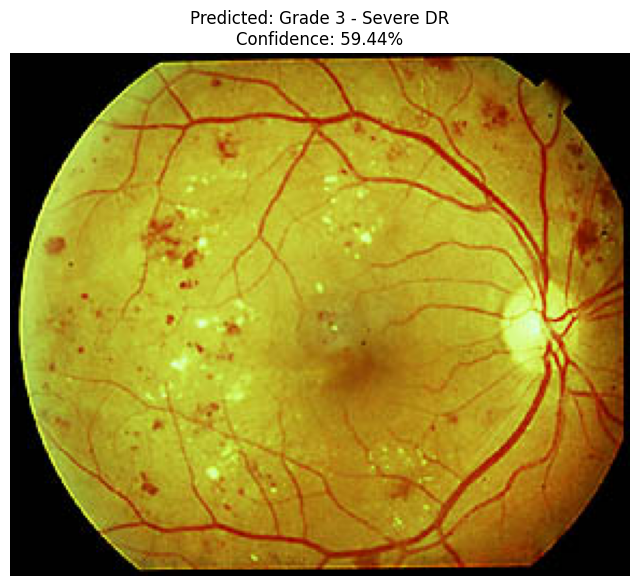

In [9]:
# ==========================================
# UNIVERSAL V2 DR IMAGE TESTER
# Upload any retinal fundus image
# ==========================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Upload image
# -----------------------------

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("❌ No image uploaded.")

image_path = next(iter(uploaded.keys()))

print(f"\n✅ Uploaded: {image_path}")


# -----------------------------
# Load image
# -----------------------------

try:
    img = Image.open(
        image_path
    ).convert("RGB")
except Exception as e:
    raise RuntimeError(
        f"❌ Could not read image: {e}"
    )


# -----------------------------
# Resize exactly as model input
# -----------------------------

img_resized = img.resize(
    (384, 384)
)


# -----------------------------
# Convert to NumPy
# -----------------------------

img_array = np.array(
    img_resized,
    dtype=np.float32
)

img_batch = np.expand_dims(
    img_array,
    axis=0
)


# -----------------------------
# V2 Prediction
# -----------------------------

probabilities = model_v2.predict(
    img_batch,
    verbose=0
)[0]


# -----------------------------
# DR Grades
# -----------------------------

grade_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]


predicted_grade = int(
    np.argmax(probabilities)
)

predicted_name = (
    grade_names[predicted_grade]
)

confidence = float(
    probabilities[predicted_grade]
)


# -----------------------------
# Referable DR
# Grade 2, 3, 4 = Referable
# -----------------------------

REFERRABLE_THRESHOLD = 0.33

referable_probability = float(
    np.sum(probabilities[2:5])
)

referable = (
    referable_probability
    >= REFERRABLE_THRESHOLD
)


# -----------------------------
# Print result
# -----------------------------

print("\n" + "=" * 60)
print("             V2 DR SCREENING RESULT")
print("=" * 60)

print(
    f"\nPredicted Grade : "
    f"{predicted_grade}"
)

print(
    f"DR Classification: "
    f"{predicted_name}"
)

print(
    f"Model Confidence: "
    f"{confidence * 100:.2f}%"
)

print(
    f"\nReferable Probability: "
    f"{referable_probability * 100:.2f}%"
)

print(
    f"Referable DR: "
    f"{'YES' if referable else 'NO'}"
)

print("\nClass Probabilities")
print("-" * 40)

for i, name in enumerate(grade_names):

    print(
        f"Grade {i} "
        f"({name:18s}) : "
        f"{probabilities[i] * 100:.2f}%"
    )

print("=" * 60)


# -----------------------------
# Display image
# -----------------------------

plt.figure(
    figsize=(8, 8)
)

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Predicted: Grade {predicted_grade} "
    f"- {predicted_name}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.show()

In [16]:
# CHECK DOWNLOADED APTOS DATASET

from pathlib import Path

APTOS_SOURCE = Path("/kaggle/input/aptos2019")

print("Dataset exists:", APTOS_SOURCE.exists())
print("\nContents:")

for item in APTOS_SOURCE.iterdir():
    print(item)

Dataset exists: True

Contents:
/kaggle/input/aptos2019/val_images
/kaggle/input/aptos2019/train_images
/kaggle/input/aptos2019/valid.csv
/kaggle/input/aptos2019/test.csv
/kaggle/input/aptos2019/train_1.csv
/kaggle/input/aptos2019/test_images


In [17]:
# ==========================================
# RESTORE TEST DATASET FROM KAGGLE CACHE
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np
import tensorflow as tf

APTOS_DIR = Path("/kaggle/input/aptos2019")

TEST_CSV = APTOS_DIR / "test.csv"
TEST_DIR = APTOS_DIR / "test_images" / "test_images"

# Load test CSV
test_df = pd.read_csv(TEST_CSV)

print("✅ Test CSV loaded")
print("Test images:", len(test_df))

# Detect columns
print("\nColumns:")
print(test_df.columns.tolist())

IMAGE_COL = test_df.columns[0]
LABEL_COL = test_df.columns[1]

print("\nImage column:", IMAGE_COL)
print("Label column:", LABEL_COL)


# ------------------------------------------
# Find image files
# ------------------------------------------

def find_image(folder, image_id):

    image_id = str(image_id)

    for ext in [".png", ".jpg", ".jpeg"]:

        path = folder / f"{image_id}{ext}"

        if path.exists():
            return str(path)

    return None


test_df["image_path"] = test_df[
    IMAGE_COL
].apply(
    lambda x: find_image(
        TEST_DIR,
        x
    )
)


# Check missing images
missing = test_df[
    "image_path"
].isna().sum()

print(
    f"\nMissing test images: {missing}"
)

if missing > 0:

    raise FileNotFoundError(
        "❌ Some test images could not be found."
    )


# ------------------------------------------
# Test image loader
# ------------------------------------------

IMG_SIZE = 384
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE


def load_test_image(
    path,
    label
):

    image = tf.io.read_file(
        path
    )

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return (
        image,
        tf.cast(
            label,
            tf.int32
        )
    )


# ------------------------------------------
# Build test dataset
# ------------------------------------------

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values.astype(str),
        test_df[LABEL_COL].values.astype(np.int32)
    )
)

test_ds = test_ds.map(
    load_test_image,
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.batch(
    BATCH_SIZE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print("\n✅ TEST DATASET READY")
print("Test images:", len(test_df))
print("Batch size:", BATCH_SIZE)


✅ Test CSV loaded
Test images: 366

Columns:
['id_code', 'diagnosis']

Image column: id_code
Label column: diagnosis

Missing test images: 0

✅ TEST DATASET READY
Test images: 366
Batch size: 16


In [18]:
# ==========================================
# V2 — FINAL TEST SET PREDICTIONS
# ==========================================

print("Running V2 predictions on test set...")

test_probabilities = model_v2.predict(
    test_ds,
    verbose=1
)

test_true = (
    test_df[LABEL_COL]
    .values
    .astype(np.int32)
)

print("\n✅ Predictions completed")

print("Prediction shape:", test_probabilities.shape)
print("True labels shape:", test_true.shape)

Running V2 predictions on test set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step

✅ Predictions completed
Prediction shape: (366, 5)
True labels shape: (366,)


In [19]:
# ==========================================
# V2 — FINAL 5-CLASS TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predicted class
test_pred = np.argmax(
    test_probabilities,
    axis=1
)

# 5-class accuracy
test_accuracy = accuracy_score(
    test_true,
    test_pred
)

print("=" * 65)
print("             V2 FINAL TEST RESULTS")
print("=" * 65)

print(
    f"\n🎯 5-Class Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

# Classification report
print("\nCLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        test_true,
        test_pred,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "No DR",
            "Mild DR",
            "Moderate DR",
            "Severe DR",
            "Proliferative DR"
        ],
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm_test = confusion_matrix(
    test_true,
    test_pred,
    labels=[0, 1, 2, 3, 4]
)

print("\nCONFUSION MATRIX")
print("=" * 65)
print(cm_test)

             V2 FINAL TEST RESULTS

🎯 5-Class Test Accuracy: 81.15%

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR     0.9751    0.9849    0.9800       199
         Mild DR     0.5625    0.6000    0.5806        30
     Moderate DR     0.6796    0.8046    0.7368        87
       Severe DR     0.1667    0.1765    0.1714        17
Proliferative DR     0.8333    0.3030    0.4444        33

        accuracy                         0.8115       366
       macro avg     0.6434    0.5738    0.5827       366
    weighted avg     0.8207    0.8115    0.8036       366


CONFUSION MATRIX
[[196   2   1   0   0]
 [  3  18   9   0   0]
 [  2   7  70   8   0]
 [  0   1  11   3   2]
 [  0   4  12   7  10]]


REFERABLE DR THRESHOLD OPTIMIZATION
Best Threshold : 0.38
Sensitivity    : 95.62%
Specificity    : 93.45%


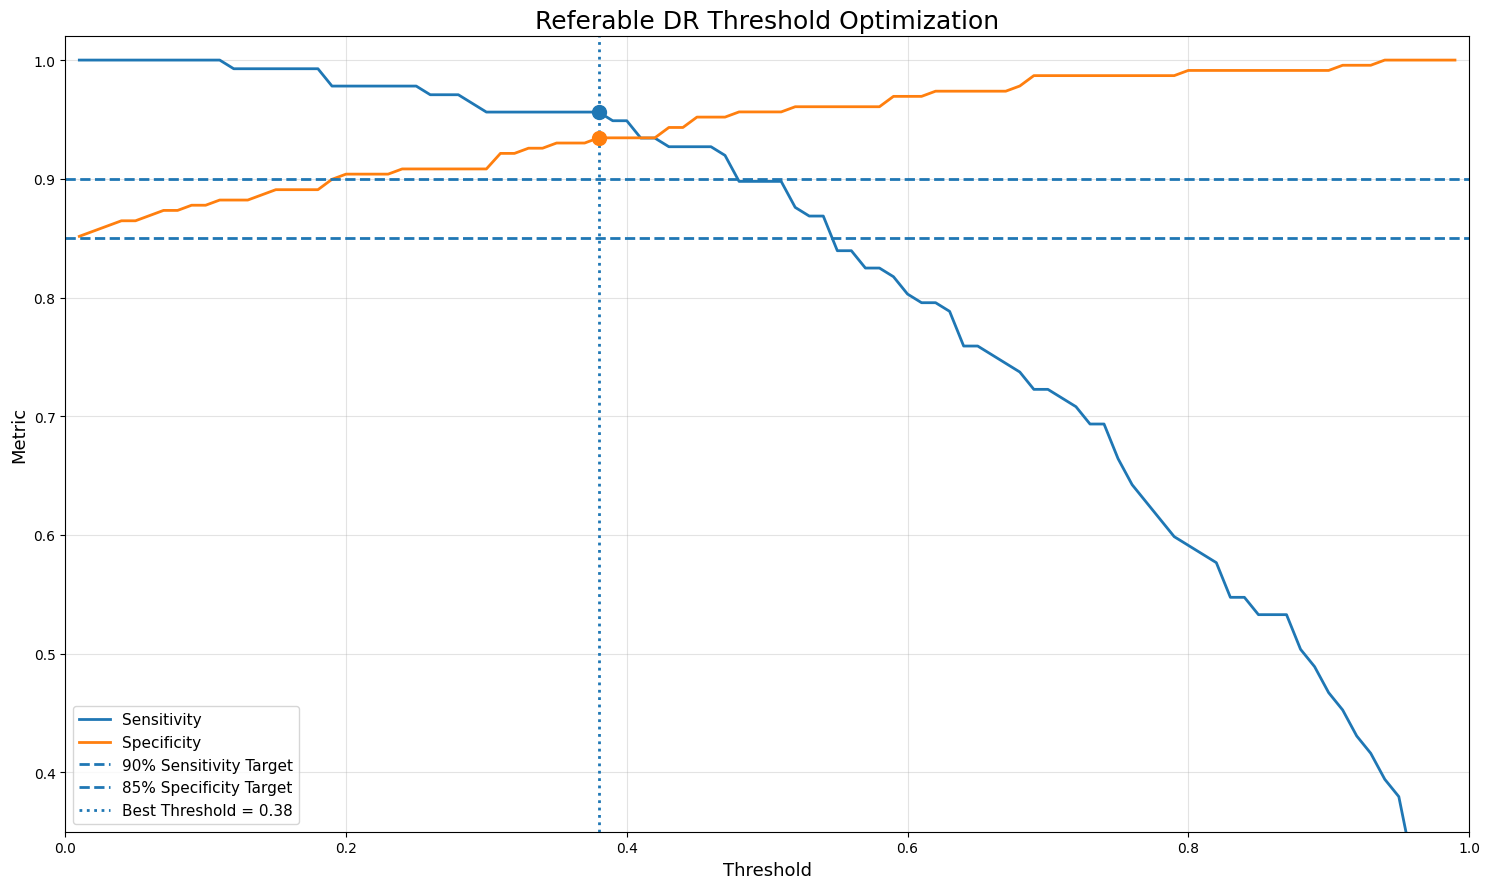

In [20]:
# ==========================================
# V2 — REFERABLE DR THRESHOLD GRAPH
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Convert 5-class probabilities into
# Referable DR probability
#
# Grade 0,1 = Non-Referable
# Grade 2,3,4 = Referable
# ------------------------------------------------

referable_probabilities = np.sum(
    test_probabilities[:, 2:5],
    axis=1
)

true_referable = (
    test_true >= 2
).astype(np.int32)


# ------------------------------------------------
# Thresholds
# ------------------------------------------------

thresholds = np.linspace(
    0.01,
    0.99,
    99
)

sensitivities = []
specificities = []


# ------------------------------------------------
# Calculate metrics at each threshold
# ------------------------------------------------

for threshold in thresholds:

    predicted_referable = (
        referable_probabilities >= threshold
    ).astype(np.int32)

    TP = np.sum(
        (true_referable == 1) &
        (predicted_referable == 1)
    )

    FN = np.sum(
        (true_referable == 1) &
        (predicted_referable == 0)
    )

    TN = np.sum(
        (true_referable == 0) &
        (predicted_referable == 0)
    )

    FP = np.sum(
        (true_referable == 0) &
        (predicted_referable == 1)
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP > 0
        else 0
    )

    sensitivities.append(
        sensitivity
    )

    specificities.append(
        specificity
    )


sensitivities = np.array(
    sensitivities
)

specificities = np.array(
    specificities
)


# ------------------------------------------------
# Target requirements
# ------------------------------------------------

SENSITIVITY_TARGET = 0.90
SPECIFICITY_TARGET = 0.85


# ------------------------------------------------
# Find best threshold satisfying both
# ------------------------------------------------

valid = (
    (sensitivities >= SENSITIVITY_TARGET) &
    (specificities >= SPECIFICITY_TARGET)
)

if np.any(valid):

    valid_indices = np.where(valid)[0]

    combined_score = (
        sensitivities[valid_indices] +
        specificities[valid_indices]
    )

    best_idx = valid_indices[
        np.argmax(combined_score)
    ]

else:

    best_idx = np.argmax(
        sensitivities + specificities
    )


best_threshold = thresholds[best_idx]
best_sensitivity = sensitivities[best_idx]
best_specificity = specificities[best_idx]


# ------------------------------------------------
# Print result
# ------------------------------------------------

print("=" * 60)
print("REFERABLE DR THRESHOLD OPTIMIZATION")
print("=" * 60)

print(
    f"Best Threshold : {best_threshold:.2f}"
)

print(
    f"Sensitivity    : "
    f"{best_sensitivity * 100:.2f}%"
)

print(
    f"Specificity    : "
    f"{best_specificity * 100:.2f}%"
)

print("=" * 60)


# ------------------------------------------------
# GRAPH
# ------------------------------------------------

plt.figure(
    figsize=(15, 9)
)

plt.plot(
    thresholds,
    sensitivities,
    linewidth=2,
    label="Sensitivity"
)

plt.plot(
    thresholds,
    specificities,
    linewidth=2,
    label="Specificity"
)

# Target lines
plt.axhline(
    SENSITIVITY_TARGET,
    linestyle="--",
    linewidth=2,
    label="90% Sensitivity Target"
)

plt.axhline(
    SPECIFICITY_TARGET,
    linestyle="--",
    linewidth=2,
    label="85% Specificity Target"
)

# Best threshold
plt.axvline(
    best_threshold,
    linestyle=":",
    linewidth=2,
    label=f"Best Threshold = {best_threshold:.2f}"
)

# Best points
plt.scatter(
    [best_threshold],
    [best_sensitivity],
    s=100,
    zorder=5
)

plt.scatter(
    [best_threshold],
    [best_specificity],
    s=100,
    zorder=5
)

# Labels
plt.title(
    "Referable DR Threshold Optimization",
    fontsize=18
)

plt.xlabel(
    "Threshold",
    fontsize=13
)

plt.ylabel(
    "Metric",
    fontsize=13
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0.35,
    1.02
)

plt.grid(
    True,
    alpha=0.35
)

plt.legend(
    loc="lower left",
    fontsize=11
)

plt.tight_layout()

plt.show()

Saving confirmed.jpeg to confirmed.jpeg

✅ Uploaded: confirmed.jpeg

             V2 DR SCREENING RESULT

Predicted Grade : 4
DR Classification: Proliferative DR
Model Confidence: 66.66%

Referable Probability: 99.91%
Referable DR: YES

Class Probabilities
----------------------------------------
Grade 0 (No DR             ) : 0.04%
Grade 1 (Mild DR           ) : 0.06%
Grade 2 (Moderate DR       ) : 4.10%
Grade 3 (Severe DR         ) : 29.15%
Grade 4 (Proliferative DR  ) : 66.66%


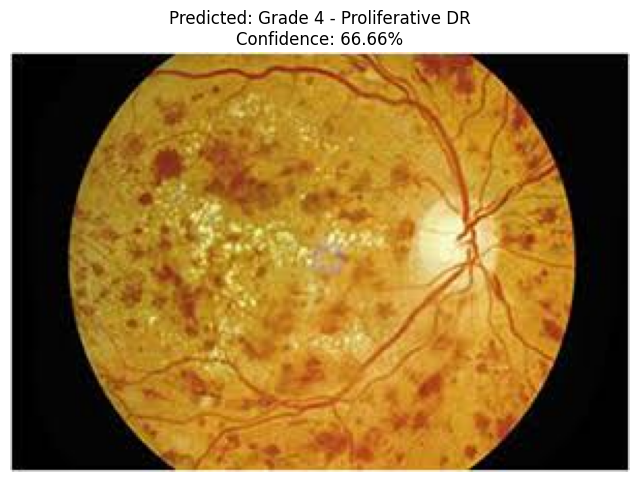

In [21]:
# ==========================================
# UNIVERSAL V2 DR IMAGE TESTER
# Upload any retinal fundus image
# ==========================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Upload image
# -----------------------------

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("❌ No image uploaded.")

image_path = next(iter(uploaded.keys()))

print(f"\n✅ Uploaded: {image_path}")


# -----------------------------
# Load image
# -----------------------------

try:
    img = Image.open(
        image_path
    ).convert("RGB")
except Exception as e:
    raise RuntimeError(
        f"❌ Could not read image: {e}"
    )


# -----------------------------
# Resize exactly as model input
# -----------------------------

img_resized = img.resize(
    (384, 384)
)


# -----------------------------
# Convert to NumPy
# -----------------------------

img_array = np.array(
    img_resized,
    dtype=np.float32
)

img_batch = np.expand_dims(
    img_array,
    axis=0
)


# -----------------------------
# V2 Prediction
# -----------------------------

probabilities = model_v2.predict(
    img_batch,
    verbose=0
)[0]


# -----------------------------
# DR Grades
# -----------------------------

grade_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]


predicted_grade = int(
    np.argmax(probabilities)
)

predicted_name = (
    grade_names[predicted_grade]
)

confidence = float(
    probabilities[predicted_grade]
)


# -----------------------------
# Referable DR
# Grade 2, 3, 4 = Referable
# -----------------------------

REFERRABLE_THRESHOLD = 0.33

referable_probability = float(
    np.sum(probabilities[2:5])
)

referable = (
    referable_probability
    >= REFERRABLE_THRESHOLD
)


# -----------------------------
# Print result
# -----------------------------

print("\n" + "=" * 60)
print("             V2 DR SCREENING RESULT")
print("=" * 60)

print(
    f"\nPredicted Grade : "
    f"{predicted_grade}"
)

print(
    f"DR Classification: "
    f"{predicted_name}"
)

print(
    f"Model Confidence: "
    f"{confidence * 100:.2f}%"
)

print(
    f"\nReferable Probability: "
    f"{referable_probability * 100:.2f}%"
)

print(
    f"Referable DR: "
    f"{'YES' if referable else 'NO'}"
)

print("\nClass Probabilities")
print("-" * 40)

for i, name in enumerate(grade_names):

    print(
        f"Grade {i} "
        f"({name:18s}) : "
        f"{probabilities[i] * 100:.2f}%"
    )

print("=" * 60)


# -----------------------------
# Display image
# -----------------------------

plt.figure(
    figsize=(8, 8)
)

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Predicted: Grade {predicted_grade} "
    f"- {predicted_name}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.show()